# 📊 Análisis Exploratorio de Datos (EDA)

Este notebook contiene el análisis exploratorio del conjunto de datos **Stroke Prediction Dataset** para comprender la distribución de las variables clínicas y demográficas, identificar valores faltantes y analizar su relación con el riesgo de accidente cerebrovascular (`stroke`).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Configuración de estilos para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

### 1. Carga de Datos y Estructura General

In [4]:
# Cargar el dataset desde la carpeta de datos crudos
df = pd.read_csv('../data/raw/healthcare-dataset-stroke-data.csv')
print(f"Dimensiones del dataset: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

Dimensiones del dataset: 5110 filas, 12 columnas


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
# Mostrar información general del dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


### 2. Análisis de Valores Faltantes (Nulos)

En la información general podemos ver que la columna `bmi` (Índice de Masa Corporal) tiene valores faltantes o valores no numéricos. Analicemos cuántos valores nulos reales tenemos.

In [6]:
# Reemplazar 'N/A' por NaN en la columna BMI si se cargó como string
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')

null_counts = df.isnull().sum()
null_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Valores Nulos': null_counts, 'Porcentaje (%)': null_percentage})
print(missing_df[missing_df['Valores Nulos'] > 0])

     Valores Nulos  Porcentaje (%)
bmi            201        3.933464


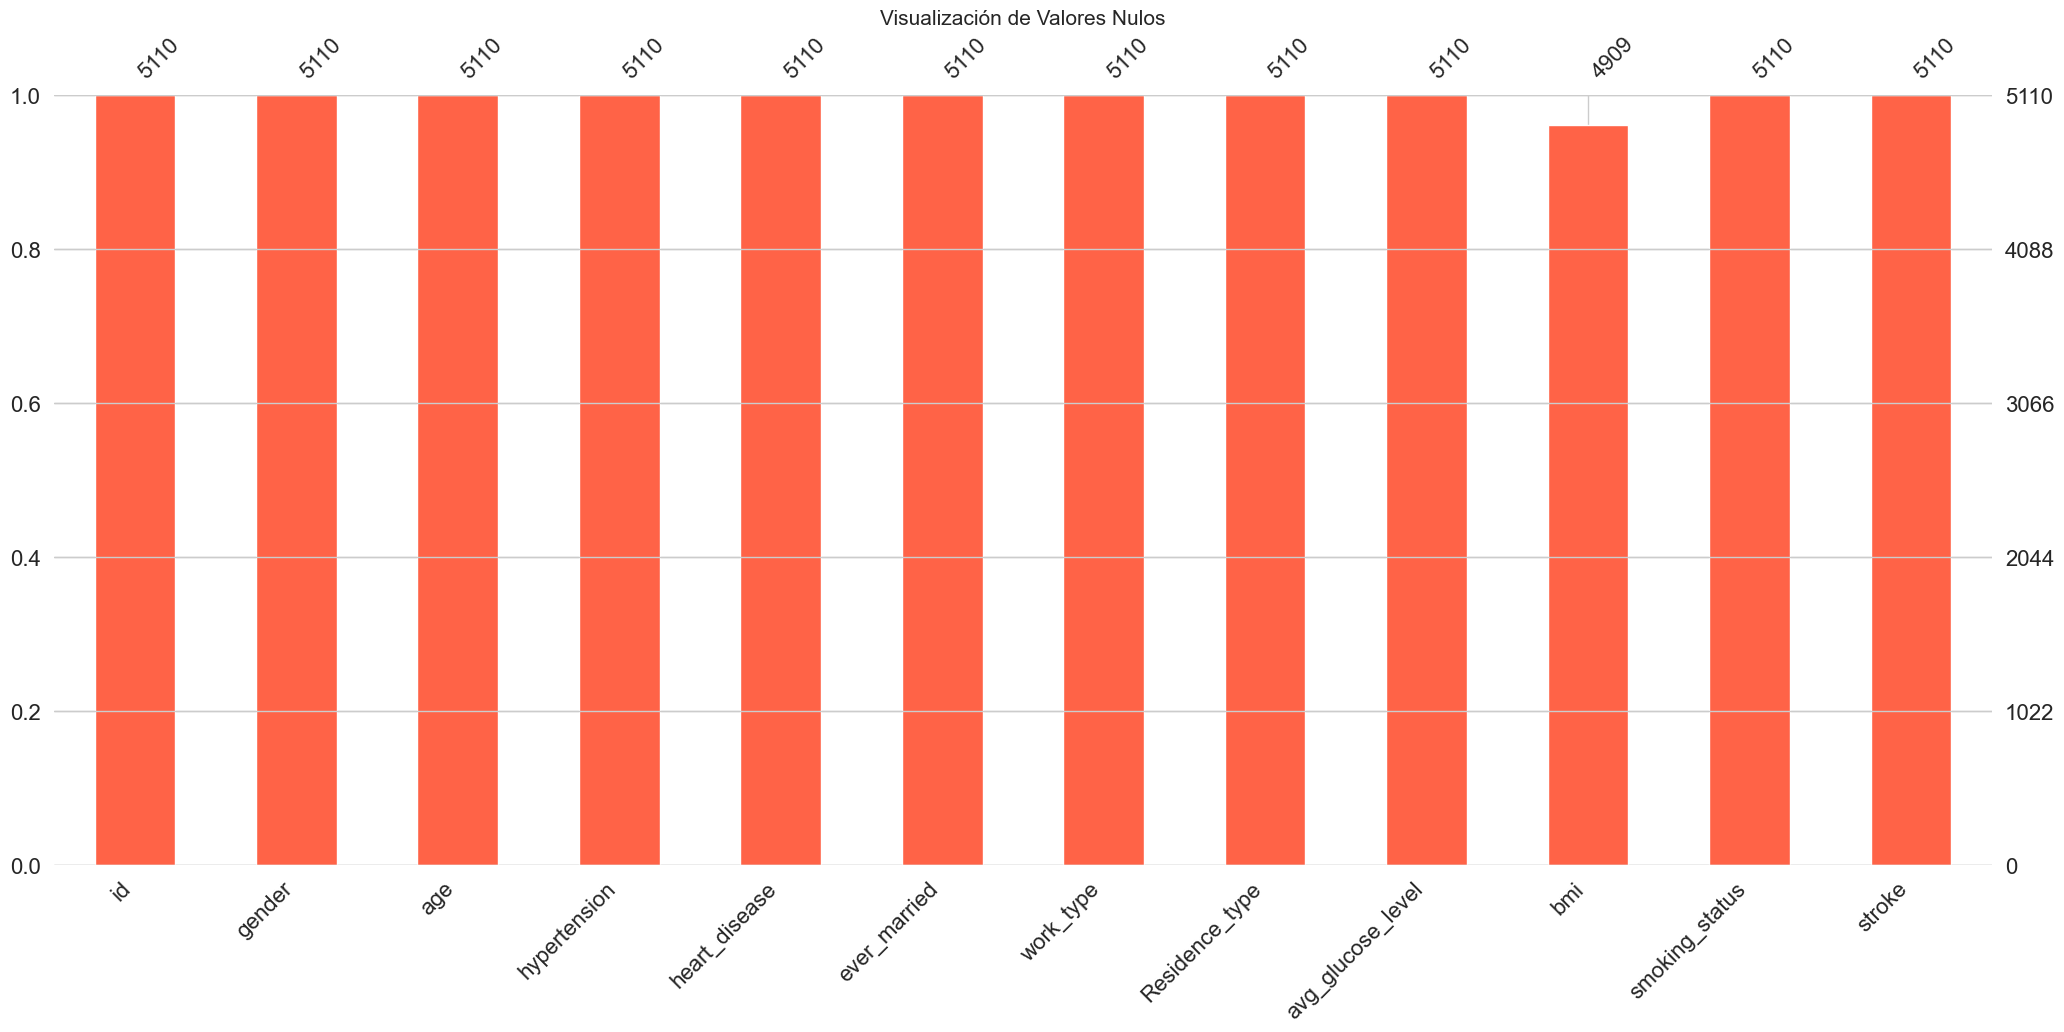

In [7]:
# Visualizar valores nulos con missingno
plt.figure(figsize=(10, 5))
msno.bar(df, color='tomato')
plt.title('Visualización de Valores Nulos', fontsize=15)
plt.show()

### 3. Distribución de la Variable Objetivo (`stroke`)

Analicemos si el dataset está balanceado o desbalanceado.

Distribución de la variable stroke:
 - Sin Riesgo (0): 4861 registros (95.13%)
 - Riesgo de ACV (1): 249 registros (4.87%)


C:\Users\ZAP\AppData\Local\Temp\ipykernel_23824\3333373018.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stroke', data=df, palette='viridis')


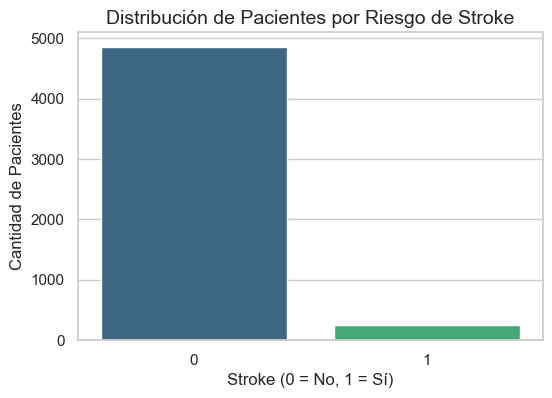

In [8]:
stroke_counts = df['stroke'].value_counts()
stroke_pct = df['stroke'].value_counts(normalize=True) * 100

print("Distribución de la variable stroke:")
for val, count, pct in zip(stroke_counts.index, stroke_counts.values, stroke_pct.values):
    label = "Riesgo de ACV (1)" if val == 1 else "Sin Riesgo (0)"
    print(f" - {label}: {count} registros ({pct:.2f}%)")

plt.figure(figsize=(6, 4))
sns.countplot(x='stroke', data=df, palette='viridis')
plt.title('Distribución de Pacientes por Riesgo de Stroke', fontsize=14)
plt.xlabel('Stroke (0 = No, 1 = Sí)')
plt.ylabel('Cantidad de Pacientes')
plt.show()

> **Nota Importante:** El dataset presenta un **fuerte desbalance de clases** (solo un 4.87% de los pacientes tienen antecedentes de stroke). Esto requerirá el uso de técnicas de sobremuestreo como SMOTE en la fase de preprocesamiento.

### 4. Distribución de Variables Categóricas

Analicemos cómo se relacionan las variables categóricas con el riesgo de sufrir un accidente cerebrovascular.

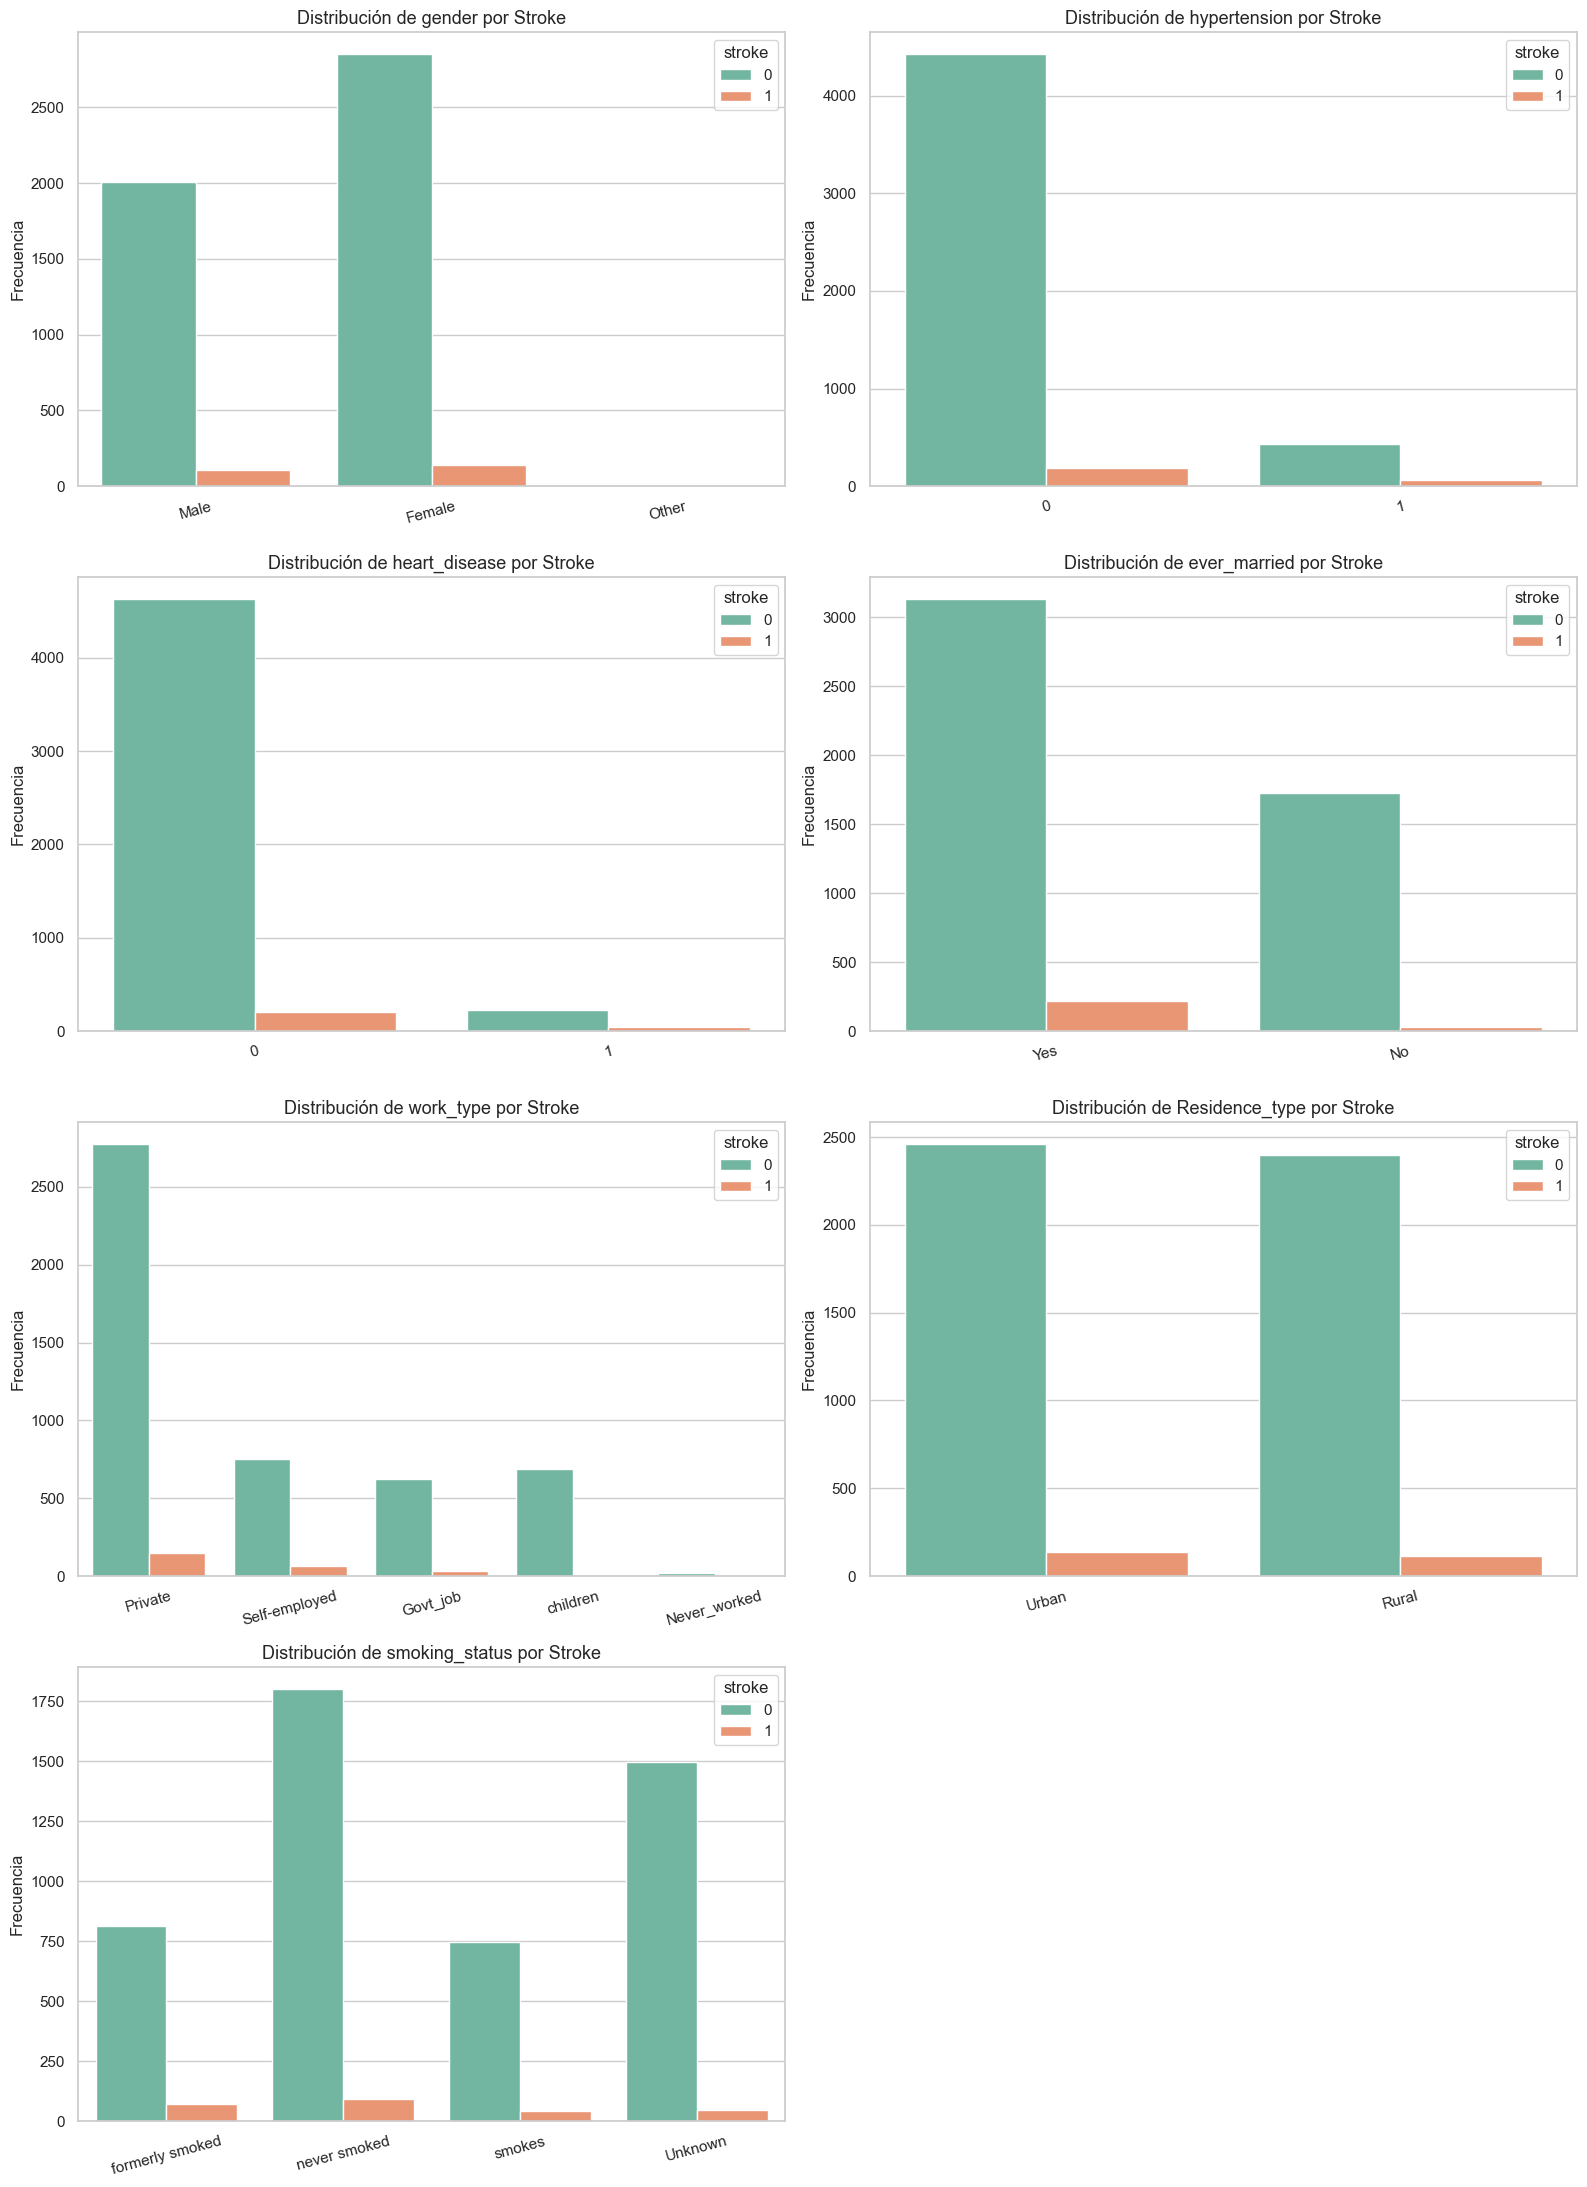

In [9]:
cat_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='stroke', data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribución de {col} por Stroke', fontsize=13)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=15)

# Ocultar el último eje que no se usa
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

### 5. Distribución de Variables Numéricas Continuas

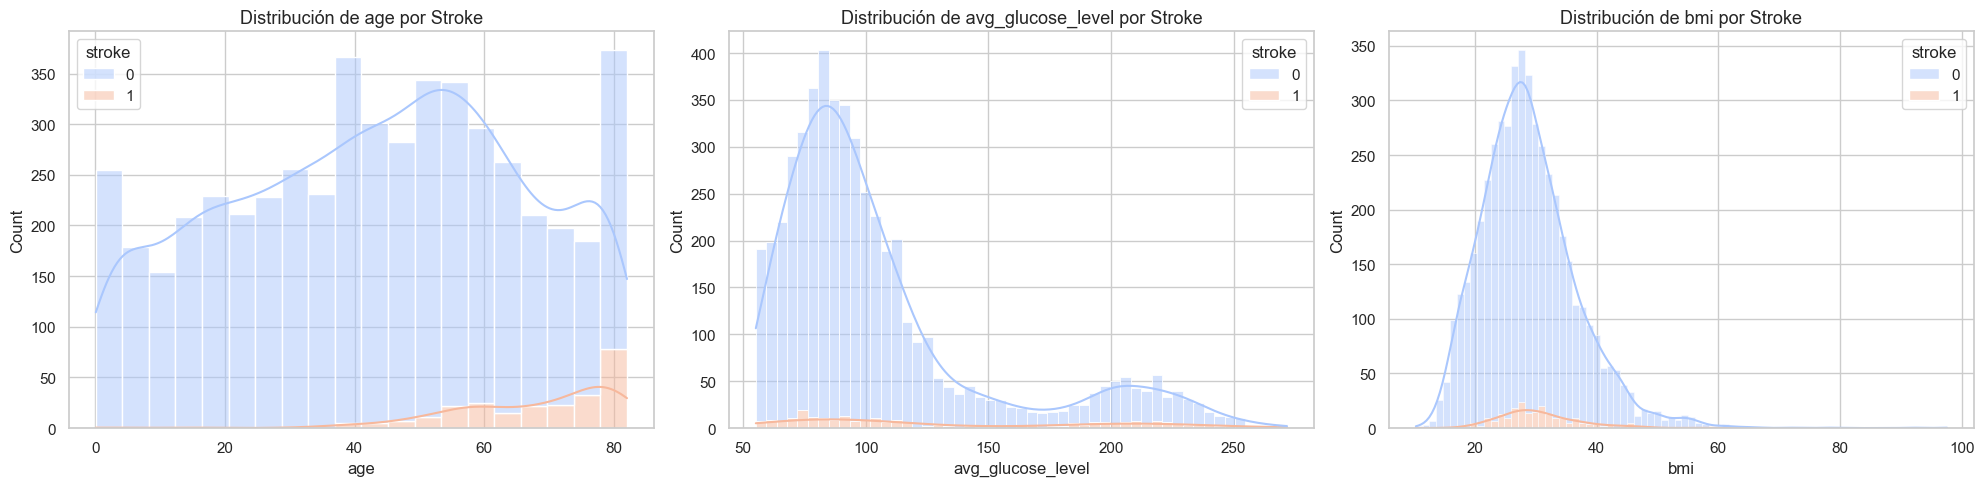

In [10]:
num_cols = ['age', 'avg_glucose_level', 'bmi']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for i, col in enumerate(num_cols):
    sns.histplot(x=col, hue='stroke', data=df, kde=True, ax=axes[i], palette='coolwarm', multiple='stack')
    axes[i].set_title(f'Distribución de {col} por Stroke', fontsize=13)

plt.tight_layout()
plt.show()

### 6. Relación de Variables Numéricas con Stroke (Boxplots)

Usemos gráficos de caja para visualizar la mediana, los cuartiles y detectar posibles valores atípicos (outliers).

C:\Users\ZAP\AppData\Local\Temp\ipykernel_23824\3434882378.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stroke', y=col, data=df, ax=axes[i], palette='pastel')
C:\Users\ZAP\AppData\Local\Temp\ipykernel_23824\3434882378.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stroke', y=col, data=df, ax=axes[i], palette='pastel')
C:\Users\ZAP\AppData\Local\Temp\ipykernel_23824\3434882378.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stroke', y=col, data=df, ax=axes[i], palette='pastel')


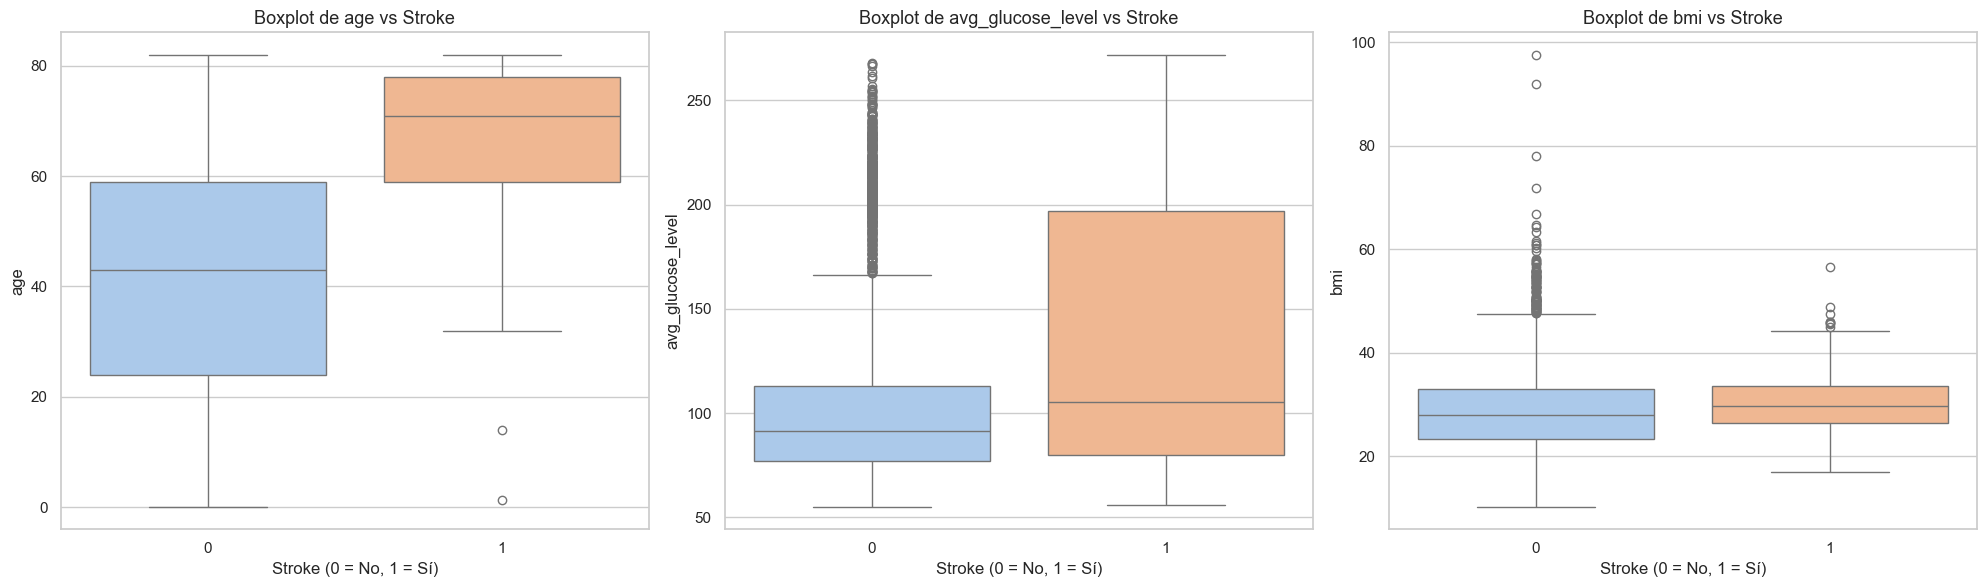

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, col in enumerate(num_cols):
    sns.boxplot(x='stroke', y=col, data=df, ax=axes[i], palette='pastel')
    axes[i].set_title(f'Boxplot de {col} vs Stroke', fontsize=13)
    axes[i].set_xlabel('Stroke (0 = No, 1 = Sí)')

plt.tight_layout()
plt.show()

### 7. Análisis de Correlación

Codifiquemos temporalmente las variables categóricas como números para visualizar la correlación lineal general.

C:\Users\ZAP\AppData\Local\Temp\ipykernel_23824\4142655828.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_encoded.select_dtypes(include=['object']).columns:


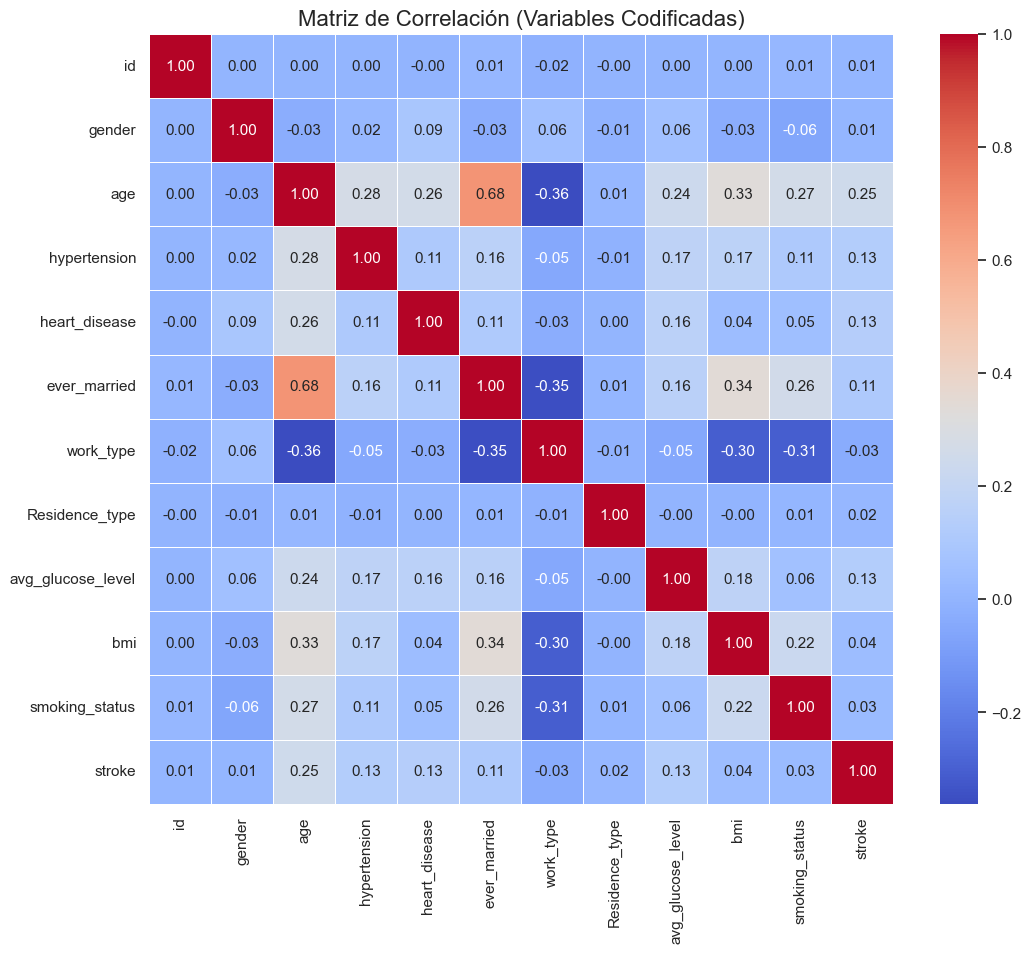

In [12]:
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)
plt.title('Matriz de Correlación (Variables Codificadas)', fontsize=16)
plt.show()

### Conclusiones del EDA
1. **Edad (`age`):** Es el factor correlacionado más fuerte con el stroke. La mayoría de los casos ocurren en pacientes mayores de 60 años.
2. **Glucosa (`avg_glucose_level`):** Pacientes con niveles elevados de glucosa muestran una mayor proporción de casos de stroke.
3. **Valores Faltantes:** La variable `bmi` tiene 201 registros nulos que requieren imputación.
4. **Desbalance de Clases:** El riesgo de stroke es minoritario (4.87%), por lo que se debe balancear con SMOTE antes de entrenar la Red Neuronal.